<a href="https://colab.research.google.com/github/Somrat390/Employee-Attrition-Prediction-Platform/blob/main/Notebooks/1_business_understanding_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

## Business Problem

Employee attrition refers to the voluntary or involuntary departure of employees from an organization. High attrition rates can negatively impact a company's productivity, increase recruitment and training costs, reduce team morale, and result in the loss of valuable knowledge and experience.

Replacing an employee is both time-consuming and expensive. Organizations invest significant resources in hiring, onboarding, and training employees. When experienced employees leave unexpectedly, these investments are lost, and business operations may be disrupted.

The objective of this project is to develop a machine learning model that predicts whether an employee is likely to leave the company based on demographic, professional, and workplace-related factors. By identifying employees who are at a high risk of attrition, Human Resources (HR) teams can take proactive retention measures such as career development opportunities, salary adjustments, workload balancing, or employee engagement programs.

This project aims to transform historical employee data into actionable insights that support data-driven decision-making and improve employee retention strategies.

# Target Variable

## The target variable in this dataset is Attrition.

Yes (1): The employee has left the company.
No (0): The employee is still working at the company.

Since the goal is to predict one of two possible outcomes (Leave or Stay), this is a Binary Classification problem.



# Project Objective

The primary objective of this project is to build an end-to-end Employee Attrition Prediction Platform capable of estimating the probability that an employee will leave the organization. In addition to generating predictions, the platform will provide interpretable insights into the key factors influencing attrition, enabling HR professionals to make informed and proactive retention decisions.

# Success Metrics

Since employee attrition datasets are typically imbalanced, relying solely on Accuracy can be misleading. For example, if most employees stay with the company, a model may achieve high accuracy simply by predicting that every employee will stay, while failing to identify those who are actually at risk of leaving.

Therefore, this project will focus on evaluation metrics that provide a more reliable assessment of model performance.

## Recall (Primary Metric)

Recall measures the proportion of employees who actually left the company that were correctly identified by the model.

A high Recall is important because failing to identify an employee who is likely to leave (False Negative) may result in unexpected resignations, increased recruitment costs, and loss of experienced talent. Therefore, maximizing Recall helps HR intervene before valuable employees resign.

## F1 Score

The F1 Score is the harmonic mean of Precision and Recall. It provides a balanced evaluation when both False Positives and False Negatives are important.

In this project, an excessively high number of False Positives would cause HR to spend unnecessary time and resources on employees who are not actually at risk, while too many False Negatives would allow high-risk employees to leave unnoticed. The F1 Score helps maintain a balance between these two types of errors.

## ROC-AUC Score

The Receiver Operating Characteristic - Area Under the Curve (ROC-AUC) measures the model's ability to distinguish between employees who are likely to leave and those who are likely to stay across different decision thresholds.

A higher ROC-AUC score indicates that the model has a stronger ability to rank high-risk employees above low-risk employees, making it a robust metric for evaluating classification performance independent of a single probability threshold.

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load The Dataset

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Basic Exploration of the Dataset

In [ ]:
df.shape

(1470, 35)

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [ ]:
df.sample(5, random_state=42)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,...,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,...,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,...,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,...,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,...,4,80,0,16,3,4,13,11,3,7


In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [ ]:
df.memory_usage(deep=True).sum() /(1024 ** 2)

np.float64(1.0161409378051758)

## Dataset Summary

- **Number of Rows:** 1,470
- **Number of Columns:** 35
- **Categorical Features:** 9
- **Numerical Features:** 26
- **Dataset Memory Usage:** Approximately 1 MB

### Initial Observations

- The dataset contains both numerical and categorical features.
- The target variable is **Attrition**, indicating whether an employee has left the company.
- The dataset appears to be well-structured and suitable for supervised binary classification.
- No conclusions regarding missing values or duplicates are made at this stage; these will be investigated during the data quality assessment.

| Feature                  | Type                        | Meaning                                                                                 |
| ------------------------ | --------------------------- | --------------------------------------------------------------------------------------- |
| Age                      | Numeric                     | Age of the employee (in years).                                                         |
| Attrition                | Target (Binary Categorical) | Whether the employee left the company (Yes/No).                                         |
| BusinessTravel           | Nominal                     | Frequency of business travel (Non-Travel, Travel Rarely, Travel Frequently).            |
| DailyRate                | Numeric                     | Daily salary rate of the employee.                                                      |
| Department               | Nominal                     | Department where the employee works.                                                    |
| DistanceFromHome         | Numeric                     | Distance between the employee's home and workplace (miles).                             |
| Education                | Ordinal                     | Education level (1 = Below College, 2 = College, 3 = Bachelor, 4 = Master, 5 = Doctor). |
| EducationField           | Nominal                     | Field of study of the employee.                                                         |
| EmployeeCount            | Numeric                     | Number of employees (constant value).                                                   |
| EmployeeNumber           | Identifier                  | Unique employee identifier.                                                             |
| EnvironmentSatisfaction  | Ordinal                     | Employee satisfaction with the work environment (1 = Low, 4 = Very High).               |
| Gender                   | Nominal                     | Gender of the employee.                                                                 |
| HourlyRate               | Numeric                     | Hourly salary rate.                                                                     |
| JobInvolvement           | Ordinal                     | Employee involvement in their job (1 = Low, 4 = Very High).                             |
| JobLevel                 | Ordinal                     | Employee job level within the company.                                                  |
| JobRole                  | Nominal                     | Employee's job role.                                                                    |
| JobSatisfaction          | Ordinal                     | Overall job satisfaction (1 = Low, 4 = Very High).                                      |
| MaritalStatus            | Nominal                     | Marital status of the employee.                                                         |
| MonthlyIncome            | Numeric                     | Monthly income of the employee.                                                         |
| MonthlyRate              | Numeric                     | Monthly salary rate.                                                                    |
| NumCompaniesWorked       | Numeric                     | Number of companies the employee has worked for previously.                             |
| Over18                   | Nominal                     | Indicates whether the employee is over 18 years old (constant value).                   |
| OverTime                 | Nominal                     | Whether the employee works overtime (Yes/No).                                           |
| PercentSalaryHike        | Numeric                     | Percentage increase in salary from the previous year.                                   |
| PerformanceRating        | Ordinal                     | Performance evaluation rating (1 = Low, 4 = Outstanding).                               |
| RelationshipSatisfaction | Ordinal                     | Satisfaction with workplace relationships (1 = Low, 4 = Very High).                     |
| StandardHours            | Numeric                     | Standard working hours (constant value).                                                |
| StockOptionLevel         | Ordinal                     | Employee stock option level.                                                            |
| TotalWorkingYears        | Numeric                     | Total years of professional work experience.                                            |
| TrainingTimesLastYear    | Numeric                     | Number of training sessions attended in the previous year.                              |
| WorkLifeBalance          | Ordinal                     | Employee work-life balance (1 = Bad, 4 = Best).                                         |
| YearsAtCompany           | Numeric                     | Total years worked at the current company.                                              |
| YearsInCurrentRole       | Numeric                     | Years spent in the current job role.                                                    |
| YearsSinceLastPromotion  | Numeric                     | Years since the employee's last promotion.                                              |
| YearsWithCurrManager     | Numeric                     | Years working with the current manager.                                                 |


# Feature Categorization

## Identifier Columns
* EmployeeNumber (Unique identifier for each employee; not useful for prediction.)

## Constant Columns

These columns contain only one unique value and do not provide any predictive information.

* EmployeeCount
* Over18
* StandardHours

These will likely be removed during preprocessing.

# High Cardinality Columns

This dataset does not contain any truly high-cardinality categorical features.

#### The feature with the highest number of categories is:

#### JobRole (9 categories)

Since it has only a small number of unique values, it is not considered high cardinality.

# Ordinal Features

These features have a natural order.

* Education
* EnvironmentSatisfaction
* JobInvolvement
* JobLevel
* JobSatisfaction
* PerformanceRating
* RelationshipSatisfaction
* StockOptionLevel
* WorkLifeBalance

# Nominal Features

These features have no inherent order.

* Attrition
* BusinessTravel
* Department
* EducationField
* Gender
* JobRole
* MaritalStatus
* Over18
* OverTime

## Initial Feature Assessment

- EmployeeNumber is a unique identifier and is not expected to contribute to predicting employee attrition.
- EmployeeCount, Over18, and StandardHours appear to have constant values and are likely to be removed during preprocessing.
- Several features, such as Education, JobLevel, JobSatisfaction, and WorkLifeBalance, are ordinal and should be encoded while preserving their natural order.
- Most categorical variables are nominal and will likely require One-Hot Encoding.
- No high-cardinality categorical features are present, simplifying the encoding process.

# Intial Data Quality Check

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


## Missing Values

The dataset contains **no missing values** across all 35 features. Therefore, no imputation techniques will be required during the preprocessing stage.

In [ ]:
df.duplicated().sum()

np.int64(0)

## Duplicate Rows

No duplicate records were found in the dataset. Each row represents a unique employee record.

In [ ]:
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


In [ ]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

constant_columns = df.columns[df.nunique() == 1]
print("Constant Columns:", list(constant_columns))

Missing Values: 0
Duplicate Rows: 0
Constant Columns: ['EmployeeCount', 'Over18', 'StandardHours']


## Constant Columns

The following columns contain only a single unique value:

- EmployeeCount
- Over18
- StandardHours

Since these features provide no variability, they do not contribute to predicting employee attrition and will likely be removed during preprocessing.


## Columns with Very Low Variance

Some features have relatively few unique values, such as:

- PerformanceRating
- StockOptionLevel
- JobLevel
- WorkLifeBalance

These features exhibit limited variability; however, they represent meaningful ordinal information and will be evaluated further during feature analysis rather than being removed solely based on their number of unique values.

## Potential Data Quality Issues

Based on the initial inspection, the following observations were made:

- No missing values are present.
- No duplicate records were found.
- Three features (EmployeeCount, Over18, and StandardHours) contain constant values and are unlikely to contribute to model performance.
- EmployeeNumber is a unique identifier and should not be used as a predictive feature.
- Several categorical and ordinal variables will require appropriate encoding during preprocessing.
- No obvious inconsistencies or invalid data entries were identified during the initial inspection.

# Exploratory Data Analysis

#### Target variable Analysis

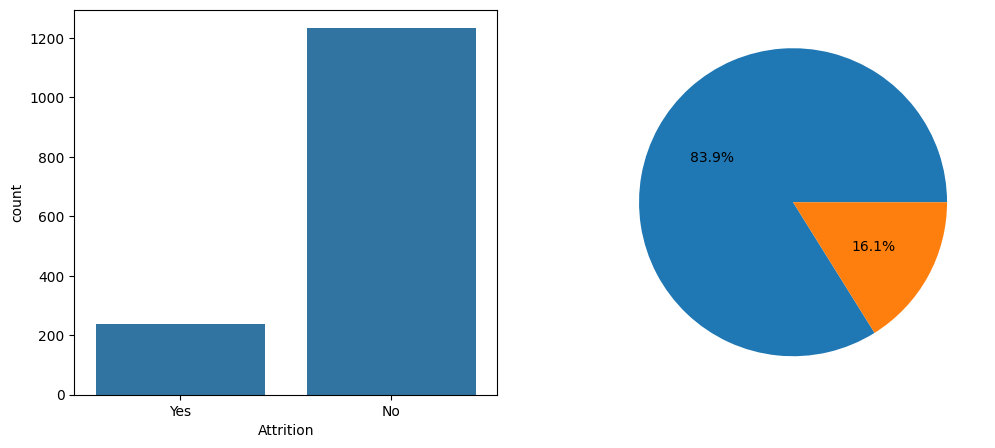

In [ ]:
attrition_count = df['Attrition'].value_counts()

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x='Attrition',ax=axes[0])

axes[1].pie(attrition_count, autopct='%1.1f%%')
plt.show()

## Target Variable Analysis

The target variable **Attrition** represents whether an employee has left the company.

- **No (Stayed):** 1,233 employees (**83.9%**)
- **Yes (Left):** 237 employees (**16.1%**)

The distribution of the target variable shows that the dataset is **imbalanced**, with the majority of employees remaining in the company. The **"No"** class dominates the dataset, while the **"Yes"** class represents a much smaller proportion of the observations.

### Challenges During Model Training

The imbalance in the target variable may introduce several challenges during model development:

- A machine learning model may become biased toward predicting the majority class (**No**).
- The model may achieve a high **Accuracy** by predicting most employees will stay, while failing to identify employees who are actually at risk of leaving.
- This may lead to a **low Recall** for the minority class (**Yes**), causing many potential attrition cases to be missed.
- Therefore, model performance should be evaluated using metrics such as **Precision**, **Recall**, **F1 Score**, and **ROC-AUC**, rather than relying solely on Accuracy.
- If class imbalance negatively impacts model performance, techniques such as **class weighting**, **SMOTE (Synthetic Minority Oversampling Technique)**, or **threshold tuning** may be explored during the model development phase.

### Business Insight

Employee attrition is relatively uncommon, with only **16.1%** of employees leaving the company. This indicates that HR retention efforts should focus on accurately identifying the small group of employees who are at a higher risk of leaving. A model that can effectively identify these employees could help the organization take proactive retention measures, reducing recruitment costs and preserving valuable talent.

# Univariate Analysis(Numerical Features)

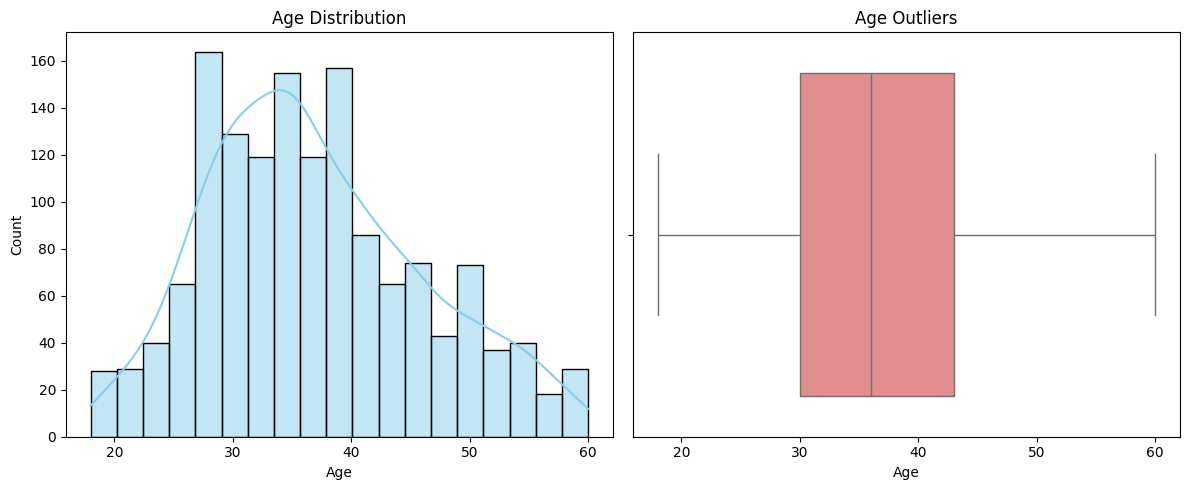

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df,x='Age',kde=True,ax=axes[0],color='skyblue')
axes[0].set_title("Age Distribution")

sns.boxplot(df,x='Age',ax=axes[1],color='lightcoral')
axes[1].set_title("Age Outliers")

plt.tight_layout()
plt.show()



### Age

- The age distribution is approximately bell-shaped with a slight right skew.
- Most employees are between **30 and 40 years** old.
- Very few employees are younger than 20 or older than 55.
- The boxplot does not indicate any significant outliers in the Age feature.

#### Business Insight

The workforce primarily consists of mid-career employees. Since there are no significant outliers, the Age feature is expected to require minimal preprocessing.

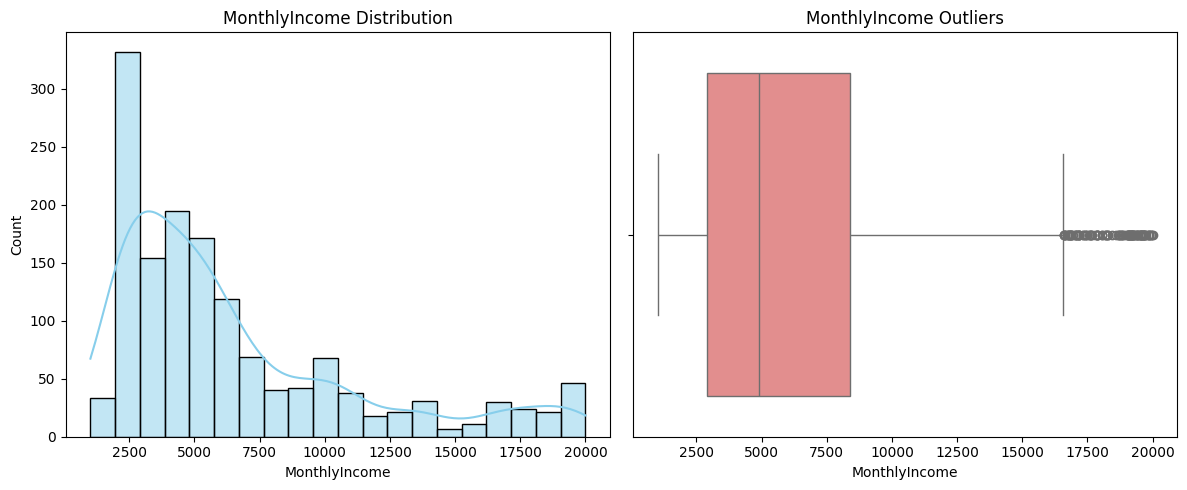

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df,x='MonthlyIncome',kde=True,ax=axes[0],color='skyblue')
axes[0].set_title("MonthlyIncome Distribution")

sns.boxplot(df,x='MonthlyIncome',ax=axes[1],color='lightcoral')
axes[1].set_title("MonthlyIncome Outliers")

plt.tight_layout()
plt.show()

### MonthlyIncome

- The MonthlyIncome distribution is highly right-skewed.
- Most employees earn lower to medium monthly incomes, while only a small number receive very high salaries.
- The boxplot reveals several high-income outliers.
- The wide spread of income values indicates considerable salary variation across employees.

#### Business Insight

Higher-income employees may represent senior or specialized positions. The presence of outliers should be investigated further before deciding whether any treatment is necessary.

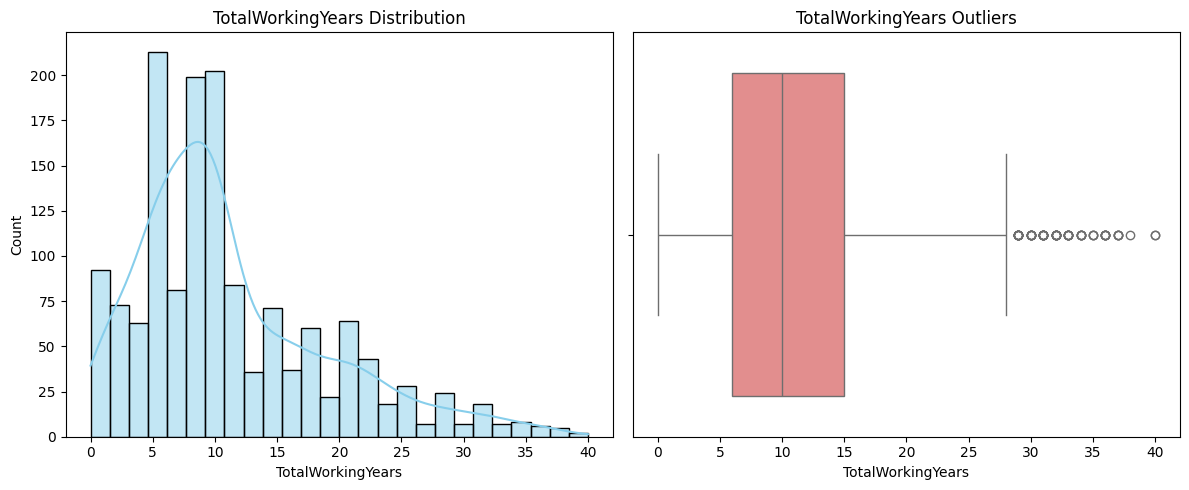

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df,x='TotalWorkingYears',kde=True,ax=axes[0],color='skyblue')
axes[0].set_title("TotalWorkingYears Distribution")

sns.boxplot(df,x='TotalWorkingYears',ax=axes[1],color='lightcoral')
axes[1].set_title("TotalWorkingYears Outliers")

plt.tight_layout()
plt.show()

### TotalWorkingYears

- The distribution is positively skewed.
- Most employees have fewer than 15 years of total work experience.
- A small number of employees have more than 30 years of experience.
- Several high-value outliers are visible in the boxplot.

#### Business Insight

The organization appears to employ a larger proportion of early- to mid-career professionals. Highly experienced employees are relatively rare but may play important leadership roles.

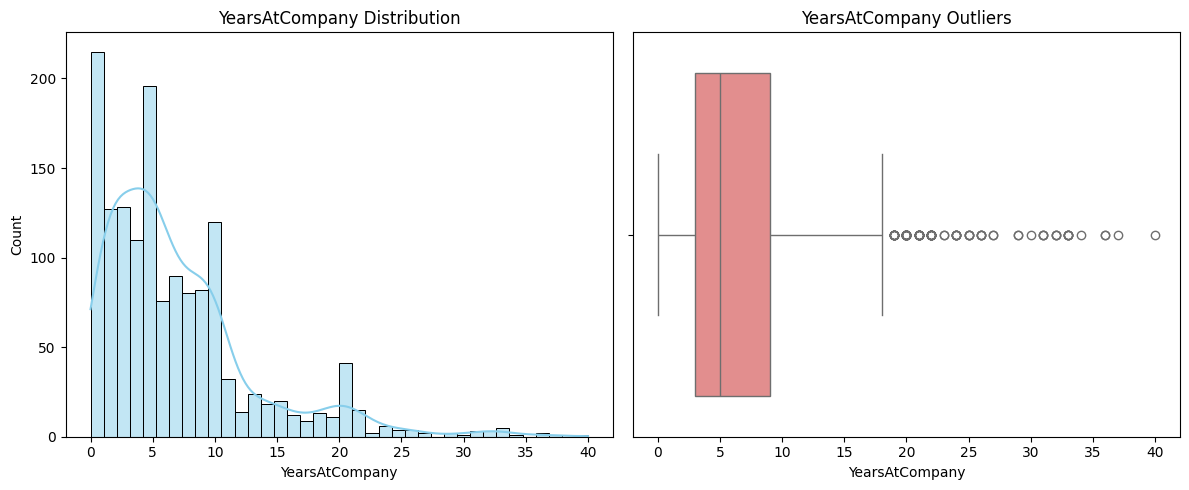

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df,x='YearsAtCompany',kde=True,ax=axes[0],color='skyblue')
axes[0].set_title("YearsAtCompany Distribution")

sns.boxplot(df,x='YearsAtCompany',ax=axes[1],color='lightcoral')
axes[1].set_title("YearsAtCompany Outliers")

plt.tight_layout()
plt.show()

### YearsAtCompany

- The distribution is strongly right-skewed.
- Most employees have worked at the company for fewer than 10 years.
- Only a small number of employees have remained with the company for more than 20 years.
- Multiple outliers are present in the upper range of the distribution.

#### Business Insight

The company has many relatively new or mid-tenure employees, while long-tenured employees form a much smaller group. Employee tenure may be an important factor influencing attrition.

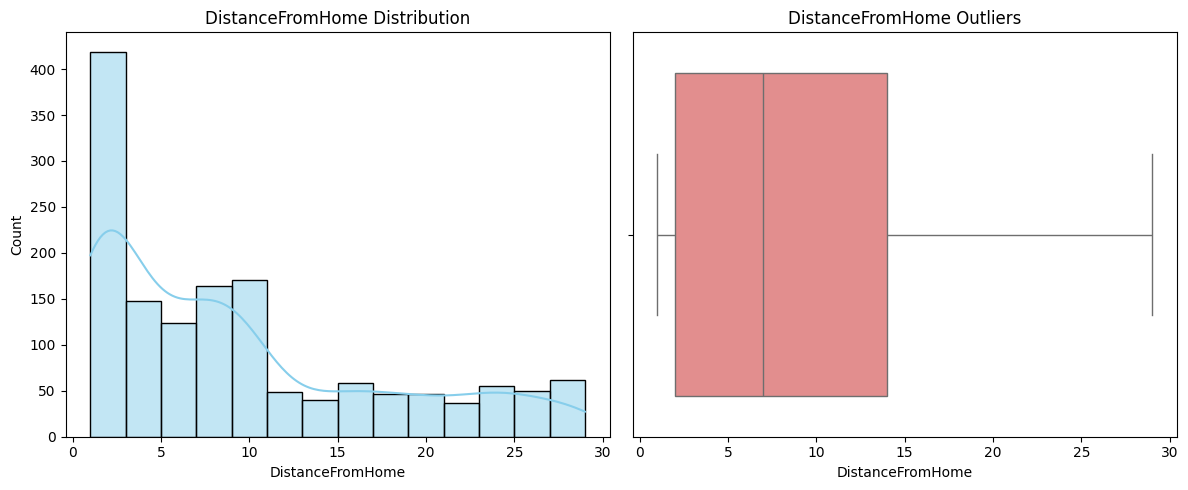

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df,x='DistanceFromHome',kde=True,ax=axes[0],color='skyblue')
axes[0].set_title("DistanceFromHome Distribution")

sns.boxplot(df,x='DistanceFromHome',ax=axes[1],color='lightcoral')
axes[1].set_title("DistanceFromHome Outliers")

plt.tight_layout()
plt.show()

### DistanceFromHome

- Most employees live relatively close to the workplace.
- The distribution is right-skewed, with fewer employees living farther away.
- No significant outliers are observed in the boxplot.
- Employees are distributed across a range of commuting distances.

#### Business Insight

Commuting distance may influence employee satisfaction and retention. This feature could be useful for understanding whether longer commutes are associated with higher attrition.

## Overall Observations

- Most numerical features exhibit a right-skewed distribution.
- MonthlyIncome, TotalWorkingYears, and YearsAtCompany contain several high-value outliers.
- Age and DistanceFromHome do not show significant outliers.
- The identified outliers may represent genuine employee records rather than data entry errors and should be investigated further before deciding on any preprocessing strategy.
- No preprocessing decisions will be made at this stage, as the objective of EDA is to understand the data rather than modify it.

# Univariate Analysis (Categorical Features)

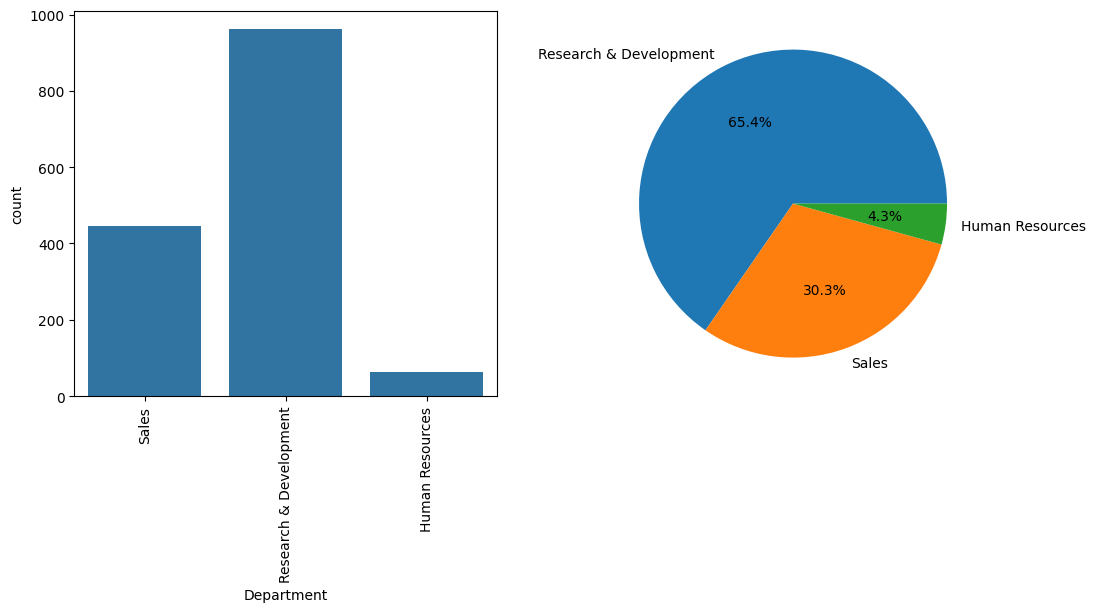

In [ ]:
department_count = df['Department'].value_counts()

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x='Department',ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)

axes[1].pie(department_count, autopct='%1.1f%%',labels=department_count.index)
plt.show()

### Department

- The **Research & Development** department has the largest number of employees, accounting for approximately **65.4%** of the workforce.
- The **Sales** department is the second largest, representing around **30.3%** of employees.
- The **Human Resources** department is the smallest, comprising only **4.3%** of the dataset.

#### Business Insight

The workforce is primarily concentrated in the Research & Development department. During later analysis, it will be valuable to investigate whether employee attrition differs across departments.

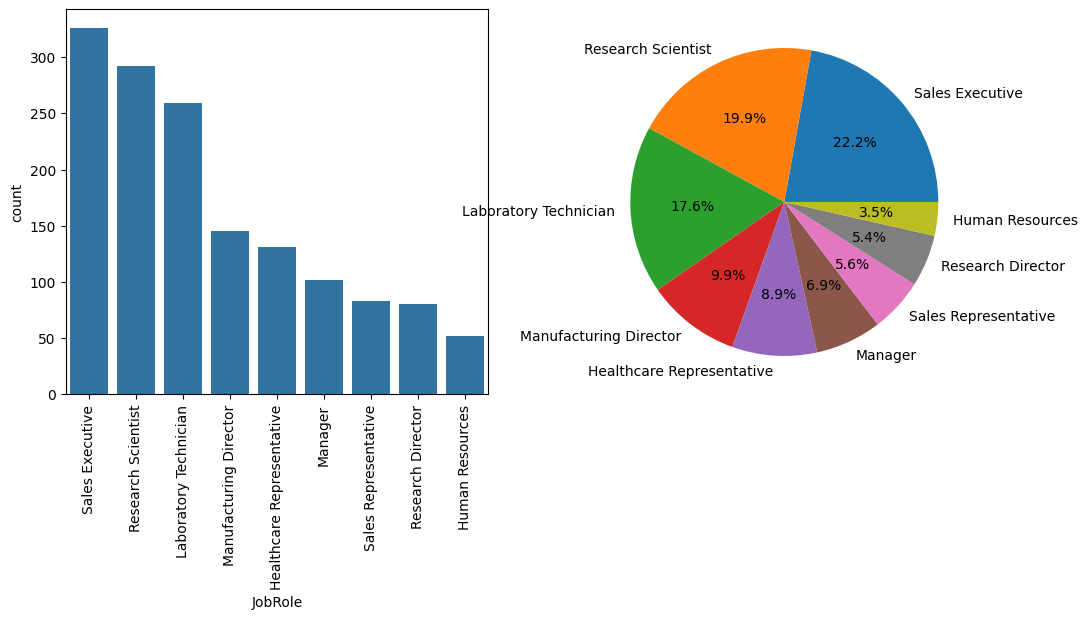

In [ ]:
JobRole_count = df['JobRole'].value_counts()

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x='JobRole',ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)

axes[1].pie(JobRole_count, autopct='%1.1f%%',labels=JobRole_count.index)
plt.show()

### JobRole

- **Sales Executive** is the most common job role, representing approximately **22.2%** of employees.
- **Research Scientist** (19.9%) and **Laboratory Technician** (17.6%) are also among the most common roles.
- **Human Resources** is the least represented job role, accounting for only **3.5%** of employees.
- The distribution of employees across job roles is uneven.

#### Business Insight

Different job roles may experience different levels of job satisfaction, workload, and career progression. Further analysis will examine whether attrition varies by job role.

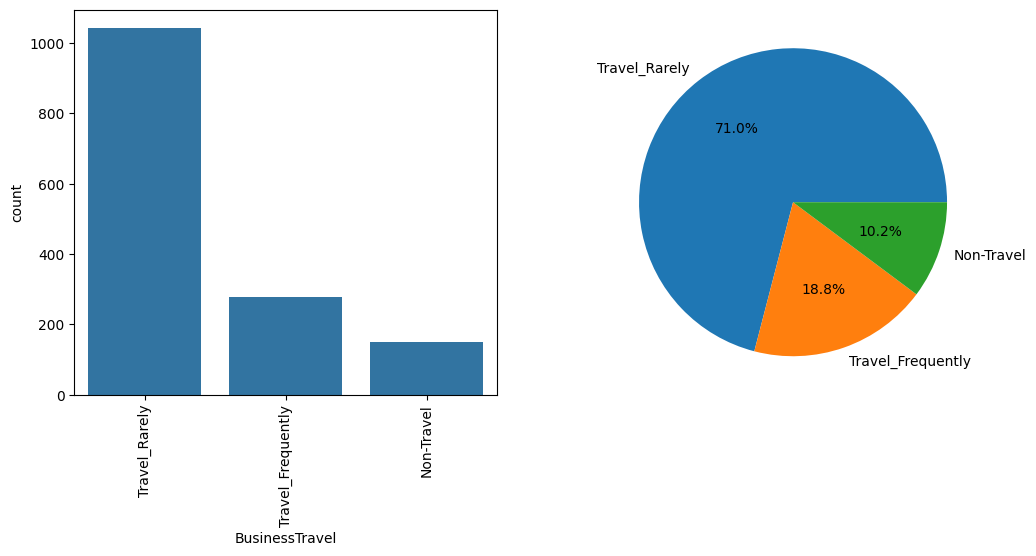

In [ ]:
BusinessTravel_count = df['BusinessTravel'].value_counts()

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x='BusinessTravel',ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)

axes[1].pie(BusinessTravel_count, autopct='%1.1f%%',labels=BusinessTravel_count.index)
plt.show()

### Business Travel

- Approximately **71.0%** of employees travel **rarely** for business.
- Around **18.8%** travel **frequently**.
- Only **10.2%** of employees do **not travel** for business.
- The majority of employees have occasional business travel responsibilities.

#### Business Insight

Business travel may influence work-life balance and employee satisfaction. It will be useful to investigate whether employees who travel frequently have a higher likelihood of attrition.

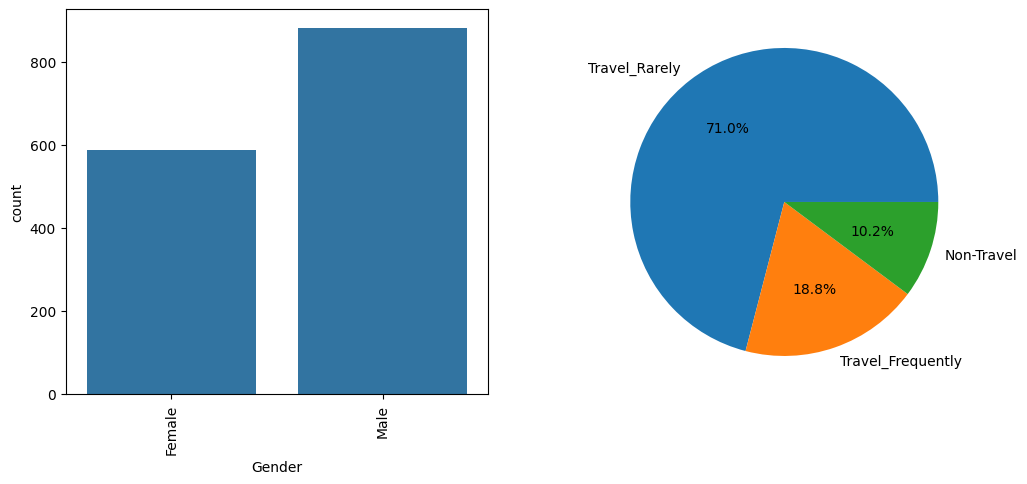

In [ ]:
Gender_count = df['BusinessTravel'].value_counts()

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x='Gender',ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)

axes[1].pie(Gender_count, autopct='%1.1f%%',labels=Gender_count.index)
plt.show()

### Gender

- The dataset contains more **Male** employees than **Female** employees.
- Male employees represent approximately **60%** of the workforce, while female employees account for about **40%**.
- Although the distribution is not perfectly balanced, both groups are well represented in the dataset.

#### Business Insight

Gender distribution appears reasonably balanced for analysis. Later, we will investigate whether attrition rates differ between male and female employees.

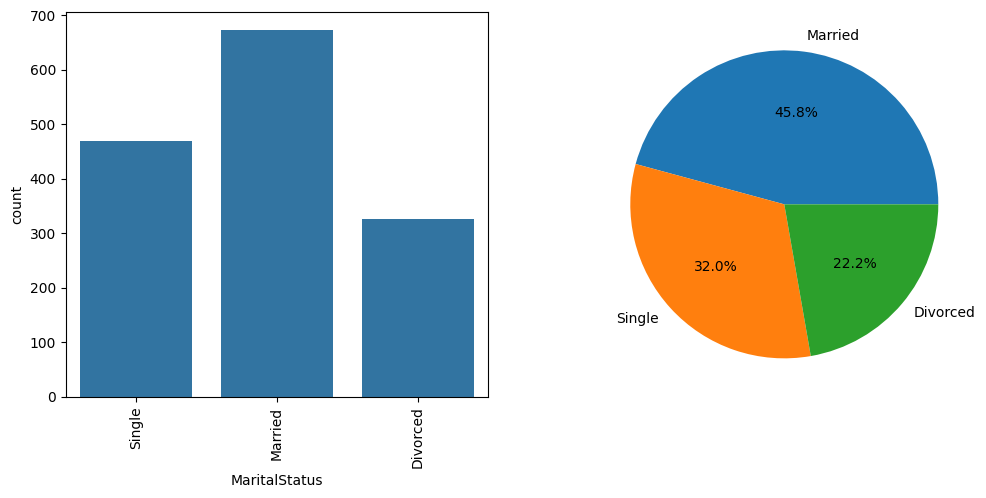

In [ ]:
MaritalStatus_count = df['MaritalStatus'].value_counts()

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x='MaritalStatus',ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)

axes[1].pie(MaritalStatus_count, autopct='%1.1f%%',labels=MaritalStatus_count.index)
plt.show()

### Marital Status

- **Married** employees form the largest group, accounting for approximately **45.8%** of the dataset.
- **Single** employees represent around **32.0%**.
- **Divorced** employees make up approximately **22.2%**.
- The employee population consists predominantly of married individuals.

#### Business Insight

Marital status may influence employee stability, work-life balance, and career decisions. Further analysis will explore whether attrition varies across different marital status groups.

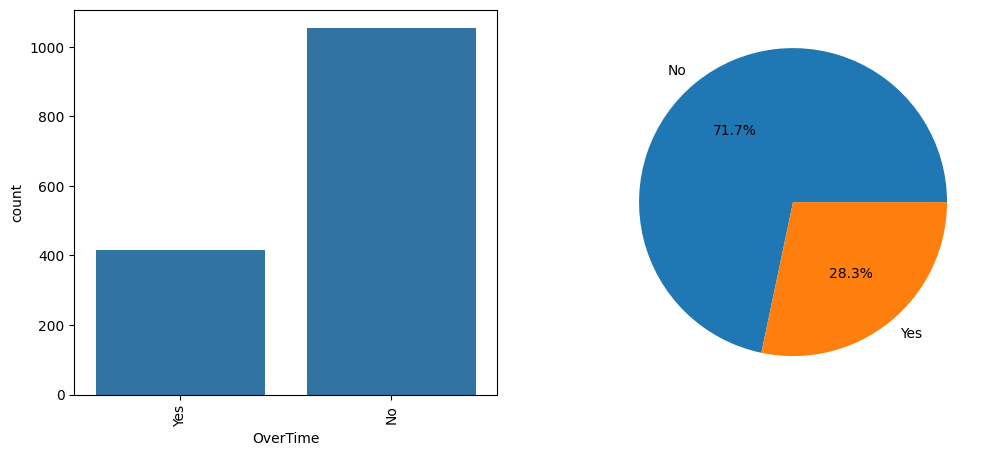

In [ ]:
OverTime_count = df['OverTime'].value_counts()

fig, axes= plt.subplots(1,2,figsize=(12,5))
sns.countplot(data=df, x='OverTime',ax=axes[0])
axes[0].tick_params(axis="x", rotation=90)

axes[1].pie(OverTime_count, autopct='%1.1f%%',labels=OverTime_count.index)
plt.show()

### Overtime

- Approximately **71.7%** of employees do **not** work overtime.
- Around **28.3%** of employees regularly work overtime.
- The majority of employees are not required to work overtime.

#### Business Insight

Overtime is often associated with increased workload and employee stress. It is an important feature that may significantly influence employee attrition and will be examined further during bivariate analysis.

## Overall Observations

- Research & Development is the largest department within the organization.
- Sales Executive is the most common job role.
- Most employees travel only rarely for business.
- The workforce contains more male employees than female employees.
- Married employees represent the largest marital status group.
- Most employees do not work overtime.
- Several categorical features exhibit uneven distributions, which may influence employee attrition.
- These features will be further analyzed against the target variable during the bivariate analysis stage to identify potential relationships with employee attrition.

# Key Findings

## Target Variable

- The target variable (**Attrition**) is imbalanced, with approximately **83.9%** of employees staying and **16.1%** leaving the company.
- This imbalance suggests that evaluation metrics such as Precision, Recall, F1 Score, and ROC-AUC will be more appropriate than Accuracy alone.

## Numerical Features

- Most numerical features exhibit positively skewed distributions.
- MonthlyIncome, TotalWorkingYears, and YearsAtCompany contain several high-value outliers that appear to represent genuine employee records.
- Age and DistanceFromHome do not show significant outliers and have relatively stable distributions.

## Categorical Features

- The majority of employees work in the **Research & Development** department.
- **Sales Executive** is the most common job role in the dataset.
- Most employees travel **rarely** for business, are **married**, and **do not work overtime**.
- The workforce contains more male employees than female employees.

## Business Insights

- Employee attrition is relatively uncommon, making the prediction problem a class-imbalanced classification task.
- Features such as **OverTime**, **Department**, **JobRole**, **BusinessTravel**, and **YearsAtCompany** may have strong relationships with employee attrition and will be investigated further during the bivariate analysis stage.

# Bivariate Analysis (Feature vs Target)

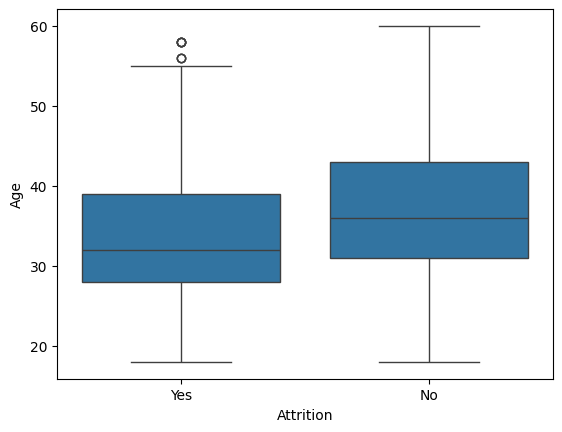

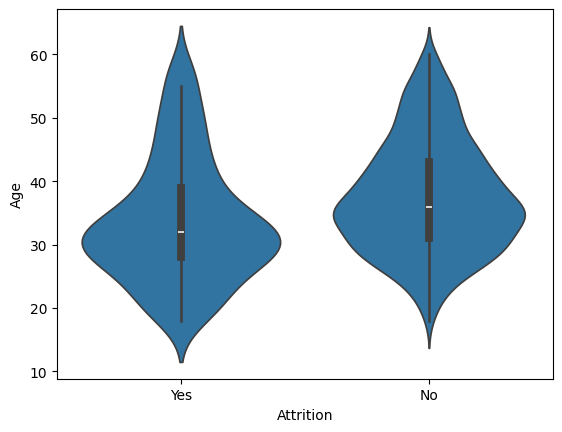

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


In [ ]:
sns.boxplot(x='Attrition',y='Age',data=df)
plt.show()
sns.violinplot(x='Attrition',y='Age',data=df)
plt.show()

df.groupby("Attrition")['Age'].describe()

### Age vs Attrition

- Employees who left the company tend to be **slightly younger** than those who stayed.
- The median age of employees with attrition is lower than that of employees without attrition.
- Although the two distributions overlap considerably, younger employees appear to have a higher tendency to leave.

#### Can this feature help predict attrition?

Yes. Age shows a noticeable difference between the two groups and may provide useful predictive information, although it is unlikely to be the strongest predictor on its own.

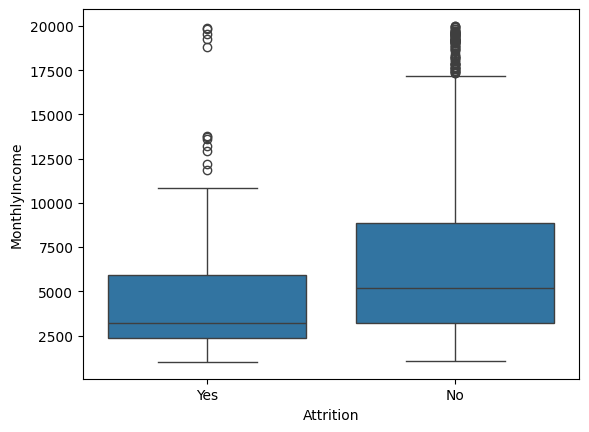

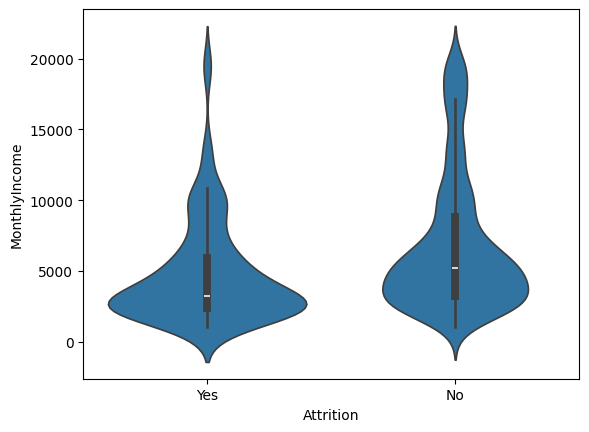

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [ ]:
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df)
plt.show()
sns.violinplot(x='Attrition',y='MonthlyIncome',data=df)
plt.show()

df.groupby("Attrition")['MonthlyIncome'].describe()

### Monthly Income vs Attrition

- Employees who left the company generally have **lower monthly incomes** than those who stayed.
- Employees who remained in the company show a wider income distribution, including many high-income individuals.
- The difference in median monthly income between the two groups is noticeable.

#### Can this feature help predict attrition?

Yes. MonthlyIncome appears to be an informative feature, as employees with lower salaries seem more likely to leave the company.

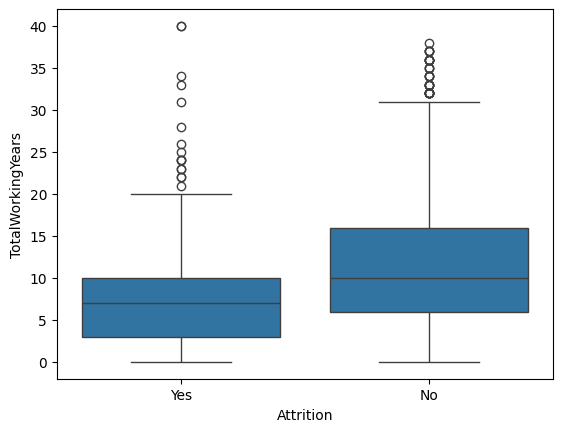

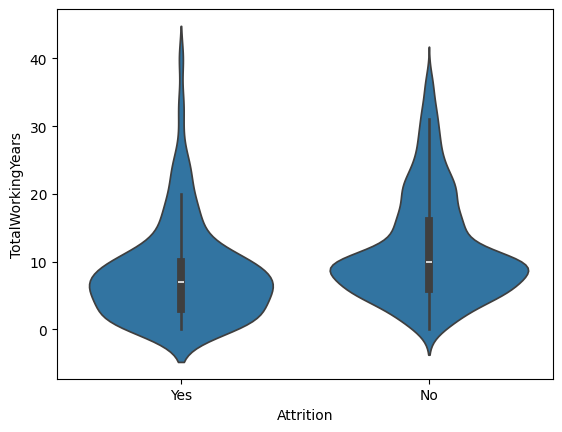

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,11.862936,7.760719,0.0,6.0,10.0,16.0,38.0
Yes,237.0,8.244726,7.169204,0.0,3.0,7.0,10.0,40.0


In [ ]:
sns.boxplot(x='Attrition',y='TotalWorkingYears',data=df)
plt.show()
sns.violinplot(x='Attrition',y='TotalWorkingYears',data=df)
plt.show()

df.groupby("Attrition")['TotalWorkingYears'].describe()

### Total Working Years vs Attrition

- Employees who left the company generally have **fewer total working years** than those who stayed.
- Employees with longer professional experience are more commonly found in the non-attrition group.
- The distributions show a visible difference in both median and spread.

#### Can this feature help predict attrition?

Yes. TotalWorkingYears appears to be a useful predictor, suggesting that less experienced employees may have a higher risk of leaving.

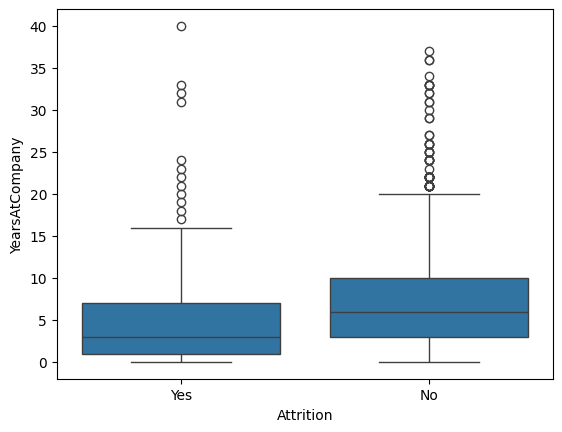

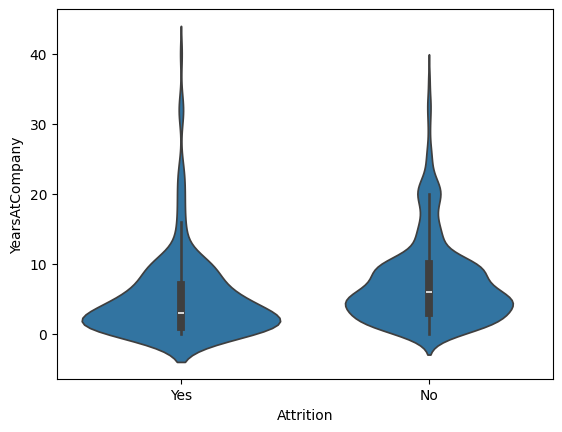

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
Yes,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


In [ ]:
sns.boxplot(x='Attrition',y='YearsAtCompany',data=df)
plt.show()
sns.violinplot(x='Attrition',y='YearsAtCompany',data=df)
plt.show()

df.groupby("Attrition")['YearsAtCompany'].describe()

### Years at Company vs Attrition

- Employees who left the company generally have **shorter tenures** than employees who stayed.
- Most attrition cases occur among employees who have spent only a few years with the company.
- Employees with longer company tenure are more likely to remain employed.

#### Can this feature help predict attrition?

Yes. YearsAtCompany appears to be one of the stronger predictors of employee attrition, as employee tenure shows a clear relationship with retention.

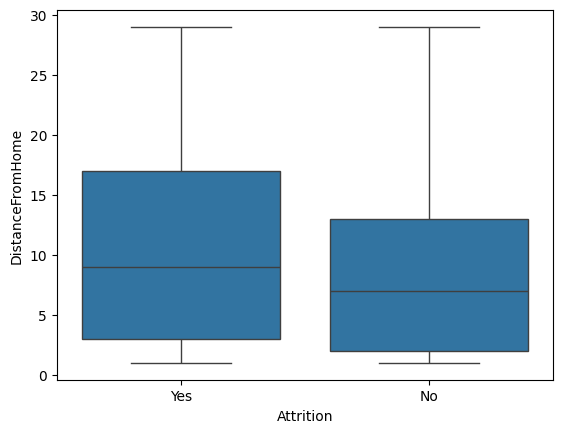

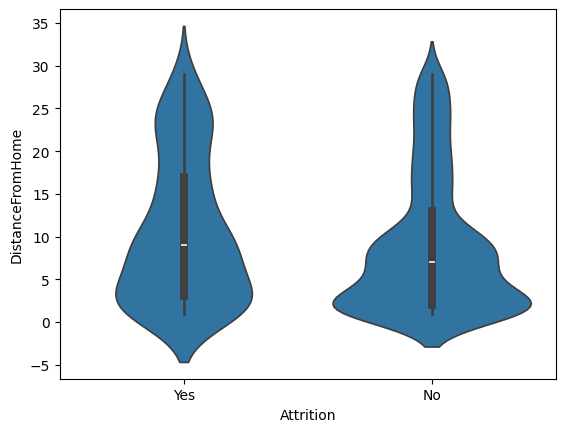

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,8.915653,8.012633,1.0,2.0,7.0,13.0,29.0
Yes,237.0,10.632911,8.452525,1.0,3.0,9.0,17.0,29.0


In [ ]:
sns.boxplot(x='Attrition',y='DistanceFromHome',data=df)
plt.show()
sns.violinplot(x='Attrition',y='DistanceFromHome',data=df)
plt.show()

df.groupby("Attrition")['DistanceFromHome'].describe()

### Distance From Home vs Attrition

- The distributions of commuting distance are similar for both groups.
- Employees who left appear to have a slightly higher median commuting distance, but the difference is relatively small.
- There is substantial overlap between the two groups.

#### Can this feature help predict attrition?

Possibly. DistanceFromHome may contribute some predictive information, but based on this analysis it appears to be a weaker predictor than features such as MonthlyIncome or YearsAtCompany.

# Categorical Feature

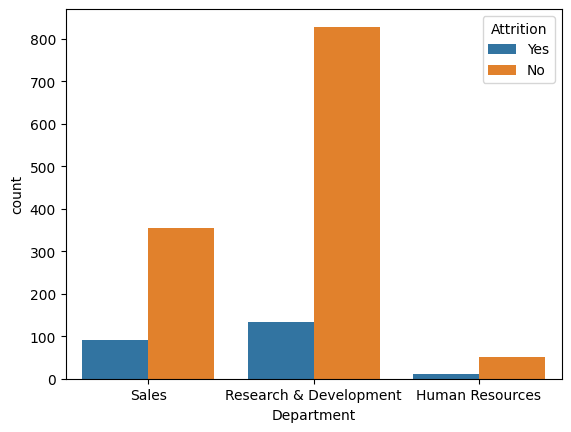

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92
Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


In [ ]:
sns.countplot(x='Department',data=df,hue='Attrition')
plt.show()
print(pd.crosstab(df['Department'], df["Attrition"]))
print(pd.crosstab(
    df['Department'],
    df["Attrition"],
    normalize="index"
) * 100)


### Department vs Attrition

- The **Sales** department has the highest attrition rate (**20.63%**), followed closely by **Human Resources (19.05%)**.
- Although **Research & Development** has the largest number of employees, it has the **lowest attrition rate (13.84%)** among the three departments.
- This indicates that employees in the Sales department are proportionally more likely to leave the company than employees in other departments.

#### Business Insight

Department appears to influence employee attrition. Employees working in the Sales department may experience factors such as higher workload, sales pressure, or limited career growth, making this feature potentially useful for predicting attrition.

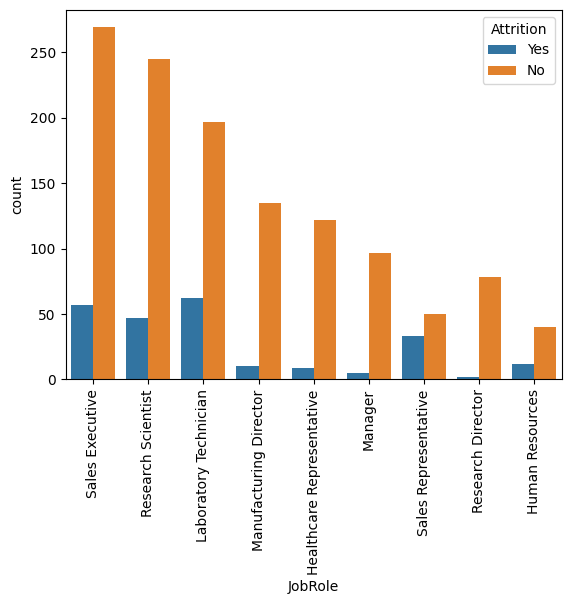

Attrition                   No  Yes
JobRole                            
Healthcare Representative  122    9
Human Resources             40   12
Laboratory Technician      197   62
Manager                     97    5
Manufacturing Director     135   10
Research Director           78    2
Research Scientist         245   47
Sales Executive            269   57
Sales Representative        50   33
Attrition                         No        Yes
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


In [ ]:
sns.countplot(x='JobRole',data=df,hue='Attrition')
plt.tick_params(axis='x',rotation=90)
plt.show()
print(pd.crosstab(df['JobRole'], df["Attrition"]))
print(pd.crosstab(
    df['JobRole'],
    df["Attrition"],
    normalize="index"
) * 100)

### Job Role vs Attrition

- **Sales Representative** has the highest attrition rate (**39.76%**), meaning nearly **4 out of every 10** employees in this role leave the company.
- **Laboratory Technician (23.94%)** and **Human Resources (23.08%)** also experience relatively high attrition rates.
- **Research Director (2.50%)** and **Manager (4.90%)** have the lowest attrition rates.
- The attrition rate varies considerably across job roles.

#### Business Insight

JobRole is likely to be one of the strongest predictors of employee attrition. Roles with higher workload, customer interaction, or fewer advancement opportunities appear to have higher employee turnover.

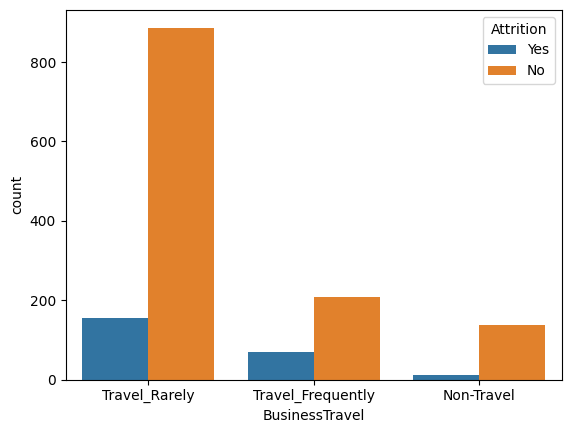

Attrition           No  Yes
BusinessTravel             
Non-Travel         138   12
Travel_Frequently  208   69
Travel_Rarely      887  156
Attrition                 No        Yes
BusinessTravel                         
Non-Travel         92.000000   8.000000
Travel_Frequently  75.090253  24.909747
Travel_Rarely      85.043145  14.956855


In [ ]:
sns.countplot(x='BusinessTravel',data=df,hue='Attrition')
plt.show()
print(pd.crosstab(df['BusinessTravel'], df["Attrition"]))
print(pd.crosstab(
    df['BusinessTravel'],
    df["Attrition"],
    normalize="index"
) * 100)

### Business Travel vs Attrition

- Employees who **travel frequently** have the highest attrition rate (**24.91%**).
- Employees who **travel rarely** have a lower attrition rate (**14.96%**).
- Employees who **do not travel** have the lowest attrition rate (**8.00%**).

#### Business Insight

Frequent business travel appears to be associated with higher employee attrition. Extensive travel may contribute to work-life imbalance, fatigue, or job dissatisfaction, making BusinessTravel an important predictive feature.

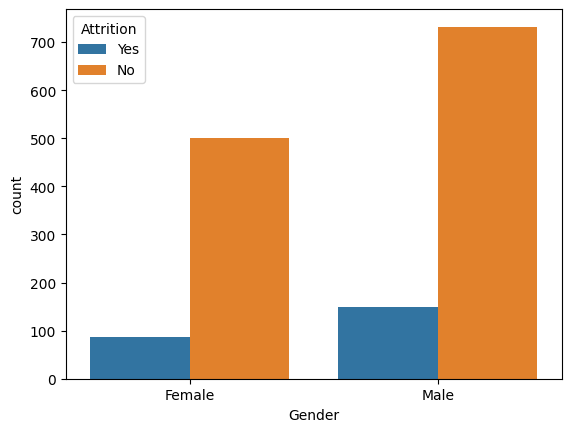

Attrition   No  Yes
Gender             
Female     501   87
Male       732  150
Attrition         No        Yes
Gender                         
Female     85.204082  14.795918
Male       82.993197  17.006803


In [ ]:
sns.countplot(x='Gender',data=df,hue='Attrition')
plt.show()
print(pd.crosstab(df['Gender'], df["Attrition"]))
print(pd.crosstab(
    df['Gender'],
    df["Attrition"],
    normalize="index"
) * 100)

### Gender vs Attrition

- Male employees have an attrition rate of **17.01%**, while female employees have an attrition rate of **14.80%**.
- The difference between the two groups is relatively small.

#### Business Insight

Gender does not appear to have a strong relationship with employee attrition. It may contribute some predictive information but is unlikely to be a dominant feature.

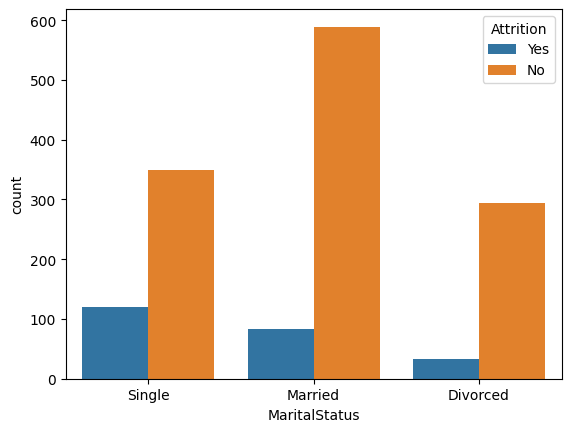

Attrition       No  Yes
MaritalStatus          
Divorced       294   33
Married        589   84
Single         350  120
Attrition             No        Yes
MaritalStatus                      
Divorced       89.908257  10.091743
Married        87.518574  12.481426
Single         74.468085  25.531915


In [ ]:
sns.countplot(x='MaritalStatus',data=df,hue='Attrition')
plt.show()
print(pd.crosstab(df['MaritalStatus'], df["Attrition"]))
print(pd.crosstab(
    df['MaritalStatus'],
    df["Attrition"],
    normalize="index"
) * 100)

### Marital Status vs Attrition

- **Single** employees have the highest attrition rate (**25.53%**).
- **Married** employees have a lower attrition rate (**12.48%**).
- **Divorced** employees have the lowest attrition rate (**10.09%**).

#### Business Insight

MaritalStatus appears to have a meaningful relationship with employee attrition. Single employees may have greater career mobility or fewer personal commitments, making them more likely to leave the organization.

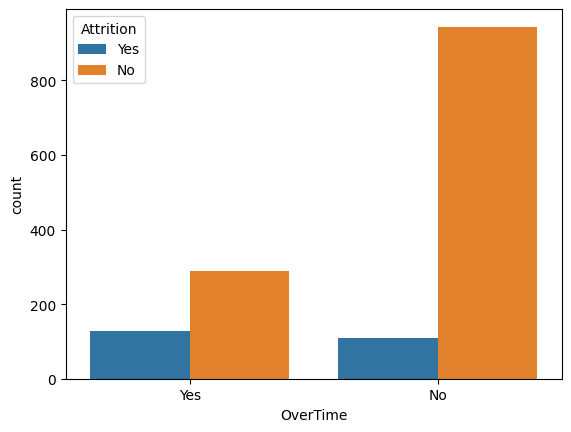

Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127
Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846


In [ ]:
sns.countplot(x='OverTime',data=df,hue='Attrition')
plt.show()
print(pd.crosstab(df['OverTime'], df["Attrition"]))
print(pd.crosstab(
    df['OverTime'],
    df["Attrition"],
    normalize="index"
) * 100)

### OverTime vs Attrition

- Employees who work **overtime** have an attrition rate of **30.53%**.
- Employees who do **not** work overtime have an attrition rate of only **10.44%**.
- The attrition rate among employees working overtime is nearly **three times higher** than that of employees who do not work overtime.

#### Business Insight

OverTime appears to be one of the strongest indicators of employee attrition. Increased workload and reduced work-life balance may significantly contribute to employees leaving the company.

# Correlation(Numerical Features)

In [ ]:
numeric_df = df.select_dtypes(include="number")

In [ ]:
numeric_df.corr()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,...,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,...,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,...,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,...,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,...,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,...,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,...,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,...,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,...,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281


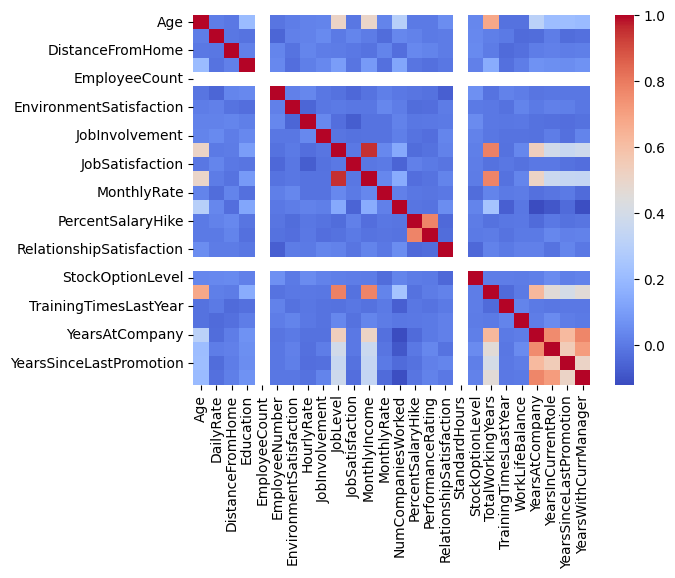

In [ ]:
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)
plt.show()

# Correlation Analysis

## Correlation Heatmap

To understand the linear relationships between numerical features, a correlation matrix was computed and visualized using a heatmap. Correlation coefficients range from **-1 to +1**, where:

- **+1** indicates a perfect positive linear relationship.
- **-1** indicates a perfect negative linear relationship.
- **0** indicates no linear relationship.

The heatmap helps identify strongly correlated features, potential multicollinearity, and relationships that may influence model performance.

---

## Observations

### Strong Positive Correlations

The following feature pairs exhibit strong positive correlations:

- **YearsAtCompany** ↔ **YearsWithCurrManager**
- **YearsAtCompany** ↔ **YearsInCurrentRole**
- **YearsInCurrentRole** ↔ **YearsWithCurrManager**
- **YearsAtCompany** ↔ **YearsSinceLastPromotion** (moderately strong)
- **PercentSalaryHike** ↔ **PerformanceRating**

These relationships are expected because the features describe related aspects of an employee's tenure, career progression, or performance evaluation.

### Strong Negative Correlations

- No numerical feature pairs exhibit strong negative correlations.
- Most negative correlations are weak and close to zero, indicating that no variables have a strong inverse linear relationship.

### Overall Correlation Pattern

- Most numerical features show **weak to moderate correlations**, suggesting that they contribute relatively independent information.
- Only a small number of tenure-related variables and the **PerformanceRating–PercentSalaryHike** pair demonstrate strong linear relationships.

---

## Multicollinearity

Several tenure-related features are highly correlated with one another:

- YearsAtCompany ↔ YearsInCurrentRole
- YearsAtCompany ↔ YearsWithCurrManager
- YearsInCurrentRole ↔ YearsWithCurrManager

These variables measure similar aspects of an employee's work history, making high correlation expected.

High correlation among predictor variables may introduce **multicollinearity**, particularly in linear models such as Logistic Regression. Multicollinearity can reduce coefficient stability and make model interpretation more difficult.

During feature engineering, these correlated features will be examined further using techniques such as:

- Variance Inflation Factor (VIF)
- Feature selection
- Model-specific feature importance

---

## Implications for Model Development

Based on the correlation analysis, the following considerations will guide the modeling phase:

- Most numerical features can be retained since they provide relatively independent information.
- Highly correlated tenure-related variables will be reviewed to minimize multicollinearity in linear models.
- Tree-based algorithms such as Random Forest, XGBoost, and CatBoost are generally less sensitive to multicollinearity and can naturally handle correlated features.
- Correlation indicates statistical association, **not causation**. Therefore, no feature will be removed solely because it is correlated with another; decisions will be based on model performance, feature importance, and domain knowledge.